# Análisis exploratorio — Colono IA

Recomendador de colocación inicial en Catan.

Este notebook explora el dataset de parejas de vértices generado por simulación y decide
qué variables entran al modelo. Corre de principio a fin sin errores, en local o en Google Colab.

**Relación con el documento final.** El notebook sigue el mismo orden que el **Capítulo 4
(Análisis exploratorio)** del documento, y cada gráfica es la misma que aparece ahí, con los
mismos colores y las mismas cifras. Al pie de cada gráfica se indica a qué figura del
documento corresponde.

**Datos:** `data/processed/parejas.csv`, generado con
`cd backend && python -m scripts.generar_dataset --tableros 200`.
Una fila por pareja de vértices candidata. La variable objetivo `puntos` es el promedio de
puntos de victoria de 40 mini-partidas simuladas de 20 rondas empezando en esa pareja.

## 1. Preparación

In [1]:
# En Google Colab, descomenta para clonar el repositorio:
# !git clone https://github.com/AnaaBohorquez/catanai.git
# %cd catanai

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.ticker import FuncFormatter

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 140)

# La raíz del proyecto: la primera carpeta, subiendo desde la actual, que tiene
# data/processed. Así funciona igual desde notebooks/, desde la raíz y en Colab.
RAIZ = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "data" / "processed").is_dir())
RUTA = RAIZ / "data" / "processed" / "parejas.csv"
IDENTIFICADORES = ["tablero_id", "pareja_id"]
OBJETIVO = "puntos"

# Las 12 variables que entran al modelo (Sección 3.5 del documento).
VARIABLES_MODELO = [
    "produccion_efectiva", "par_camino", "par_ciudad", "trio_desarrollo",
    "cuarteto_poblado", "desequilibrio", "puerto_alineado", "puerto_generico",
    "vertices_expansion_2", "jugadores", "num_hexagonos", "solapamiento",
]

In [2]:
# Estilo de las gráficas: el mismo del documento.
# Paleta tomada del logo de Colono IA, validada para que los colores se distingan
# también con daltonismo.
AZUL, TERRACOTA, VERDE, DORADO = "#2F6AA3", "#C8643C", "#1F978A", "#A8861F"
TINTA, TENUE, REJILLA, GRIS = "#2b2b2b", "#6b6b6b", "#e6e6e6", "#9e9e9e"

plt.rcParams.update({
    "font.family": "DejaVu Sans", "font.size": 9,
    "axes.edgecolor": "#bdbdbd", "axes.labelcolor": TINTA,
    "xtick.color": TENUE, "ytick.color": TENUE,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": REJILLA, "grid.linewidth": 0.6, "axes.axisbelow": True,
    "axes.titlesize": 10, "axes.titleweight": "bold", "axes.titlecolor": TINTA,
    "figure.dpi": 110,
})

## 2. Los datos

In [3]:
datos = pd.read_csv(RUTA)
variables = [c for c in datos.columns if c not in IDENTIFICADORES + [OBJETIVO]]

print(f"Filas:               {len(datos):,}")
print(f"Tableros:            {datos['tablero_id'].nunique()}")
print(f"Parejas por tablero: {datos.groupby('tablero_id').size().min()} a {datos.groupby('tablero_id').size().max()}")
print(f"Variables:           {len(variables)}")
print(f"Valores faltantes:   {int(datos.isna().sum().sum())}")
print(f"Filas duplicadas:    {int(datos.duplicated(IDENTIFICADORES).sum())}")
print(f"Tableros con 3 / 4 jugadores: "
      f"{(datos.groupby('tablero_id')['jugadores'].first() == 3).sum()} / "
      f"{(datos.groupby('tablero_id')['jugadores'].first() == 4).sum()}")

datos.head(3)

Filas:               38,355
Tableros:            200
Parejas por tablero: 186 a 198
Variables:           40
Valores faltantes:   0
Filas duplicadas:    0
Tableros con 3 / 4 jugadores: 100 / 100


,tablero_id,pareja_id,puntos,pips_totales,num_hexagonos,hexagonos_distintos,num_recursos_distintos,pips_madera,pips_ladrillo,pips_trigo,pips_oveja,pips_mineral,toca_desierto,num_puertos,puerto_generico,puerto_especifico,jugadores,par_camino,par_ciudad,trio_desarrollo,cuarteto_poblado,control_madera,control_ladrillo,control_trigo,control_oveja,control_mineral,control_suministro,control_maximo,desequilibrio,puerto_alineado,produccion_efectiva,turnos_a_camino,turnos_a_poblado,turnos_a_ciudad,turnos_a_carta_desarrollo,vertices_expansion_2,vertices_expansion_3,pips_vecinos_max,pips_vecinos_media,aristas_cercanas,solapamiento,distancia,complementariedad
0,1,"(-1,0)|(0,-1)|(0,0) + (-2,0)|(-2,1)|(-1,0)",7.400,24.0,6.0,5.0,4.0,12.0,4.0,4.0,4.0,0.0,0.0,0.0,0.0,0.0,3.0,4.0,0.000000,0.0,4.0,0.705882,0.571429,0.266667,0.363636,0.00,1.907614,0.705882,0.500000,0.0,18.6,3.0,3.000000,12.0,4.000000,8.0,10.0,11.0,6.444444,40.0,1.0,3.0,1.0
1,1,"(-1,0)|(0,-1)|(0,0) + (-2,0)|(-1,-1)|(-1,0)",7.150,24.0,6.0,5.0,5.0,10.0,4.0,4.0,4.0,2.0,0.0,0.0,0.0,0.0,3.0,4.0,0.666667,2.0,4.0,0.588235,0.571429,0.266667,0.363636,0.25,2.039967,0.588235,0.416667,0.0,20.1,3.0,3.000000,18.0,6.000000,8.0,9.0,11.0,6.470588,40.0,1.0,2.0,2.0
2,1,"(-1,0)|(0,-1)|(0,0) + (0,-2)|(0,-1)|(1,-2)",6.675,24.0,6.0,5.0,4.0,5.0,4.0,0.0,11.0,4.0,0.0,0.0,0.0,0.0,3.0,4.0,0.000000,0.0,0.0,0.294118,0.571429,0.000000,1.000000,0.50,2.365546,1.000000,0.458333,0.0,19.2,3.0,4.363636,9.0,4.363636,8.0,10.0,11.0,6.500000,40.0,1.0,3.0,1.0


### Por qué no hay valores faltantes

Los datos no vienen de una fuente externa: los genera el propio simulador. Cada variable se
calcula con una fórmula que siempre devuelve un número, y `variables.py` lo verifica con
`verificar_variables()`, que falla si aparece un `None`, un `NaN` o un infinito.

Esto ahorra el trabajo de imputación, pero traslada la exigencia a otro lado: hay que
comprobar que las variables **tengan sentido** y que **varíen**, que es lo que hace el
resto de este notebook.

## 3. Análisis univariado

### 3.1 La variable objetivo

In [4]:
y = datos[OBJETIVO]
resumen = pd.DataFrame({
    "Media": [y.mean()], "Desv.": [y.std()], "Mín.": [y.min()], "Q1": [y.quantile(0.25)],
    "Mediana": [y.median()], "Q3": [y.quantile(0.75)], "Máx.": [y.max()],
    "Asimetría": [y.skew()], "Curtosis": [y.kurt()],
}).round(2)
resumen

,Media,Desv.,Mín.,Q1,Mediana,Q3,Máx.,Asimetría,Curtosis
0,4.66,1.57,2.0,3.6,4.2,5.48,14.55,1.25,1.93


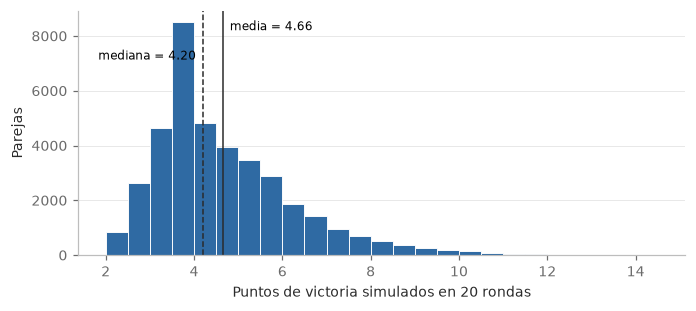

In [5]:
fig, ax = plt.subplots(figsize=(6.4, 2.9))
ax.hist(y, bins=np.arange(2, 15, 0.5), color=AZUL, edgecolor="white", linewidth=0.6)
ax.axvline(y.mean(), color=TINTA, lw=1)
ax.axvline(y.median(), color=TINTA, lw=1, ls="--")
ax.text(y.mean() + 0.15, ax.get_ylim()[1] * 0.92, f"media = {y.mean():.2f}", fontsize=8)
ax.text(y.median() - 0.15, ax.get_ylim()[1] * 0.80, f"mediana = {y.median():.2f}", fontsize=8, ha="right")
ax.set_xlabel("Puntos de victoria simulados en 20 rondas")
ax.set_ylabel("Parejas")
ax.grid(axis="x", visible=False)
plt.tight_layout()
plt.show()

*Documento, Capítulo 4: figura «Distribución de los puntos simulados».*

La distribución tiene **sesgo a la derecha**: la mayoría de las parejas se agrupa entre 3 y 6
puntos, y la media queda por encima de la mediana por una cola pequeña que llega mucho más alto.
Eso es lo esperable y es buena señal para el producto: las parejas realmente buenas son raras,
y encontrarlas es justo lo que la app aporta.

Lo que importa para la app no es la escala absoluta, sino la diferencia **dentro de un mismo
tablero**, que es la decisión que enfrenta el jugador:

In [6]:
por_tablero = datos.groupby("tablero_id")[OBJETIVO]
print(f"Mejor pareja de cada tablero (promedio): {por_tablero.max().mean():.2f} puntos")
print(f"Pareja típica:                           {por_tablero.mean().mean():.2f} puntos")
print(f"Peor pareja de cada tablero (promedio):  {por_tablero.min().mean():.2f} puntos")

Mejor pareja de cada tablero (promedio): 8.92 puntos
Pareja típica:                           4.66 puntos
Peor pareja de cada tablero (promedio):  2.33 puntos


### 3.2 Valores extremos

In [7]:
q1, q3 = y.quantile([0.25, 0.75])
limite_superior = q3 + 1.5 * (q3 - q1)
limite_inferior = q1 - 1.5 * (q3 - q1)
extremos = datos[y > limite_superior]

print(f"Límite superior (Q3 + 1.5·RIC): {limite_superior:.2f} puntos")
print(f"Parejas por encima: {len(extremos):,} ({len(extremos) / len(datos):.1%})")
print(f"Parejas por debajo del límite inferior: {int((y < limite_inferior).sum())}")
print("\nCómo son las parejas extremas frente al resto (promedios):")
comparar = ["produccion_efectiva", "cuarteto_poblado", "par_camino", "desequilibrio"]
pd.DataFrame({
    "extremas": extremos[comparar].mean(),
    "resto": datos.loc[y <= limite_superior, comparar].mean(),
}).round(2)

Límite superior (Q3 + 1.5·RIC): 8.29 puntos
Parejas por encima: 1,331 (3.5%)
Parejas por debajo del límite inferior: 0

Cómo son las parejas extremas frente al resto (promedios):


,extremas,resto
produccion_efectiva,17.74,13.43
cuarteto_poblado,2.36,0.37
par_camino,4.28,1.39
desequilibrio,0.36,0.47


Estas parejas **no se eliminan**. En un dataset generado por simulación no hay errores de
captura: cada tablero pasa una verificación automática y cada valor es el promedio de 40
partidas simuladas. Como muestra la tabla, las parejas extremas producen más y combinan mejor
los recursos: son las mejores colocaciones de cada tablero. Quitarlas significaría eliminar
del entrenamiento justo los casos que la app tiene que aprender a reconocer.

### 3.3 Las variables del modelo

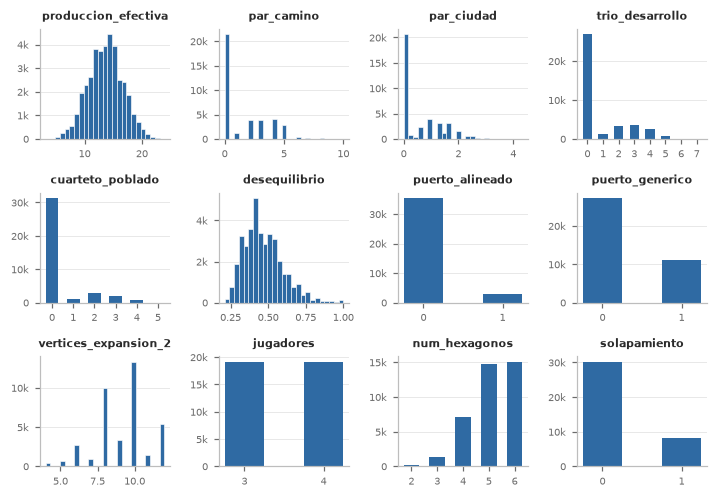

In [8]:
fig, axs = plt.subplots(3, 4, figsize=(6.6, 4.6))
miles = FuncFormatter(lambda x, p: f"{x / 1000:.0f}k" if x >= 1000 else f"{x:.0f}")
for ax, v in zip(axs.flat, VARIABLES_MODELO):
    s = datos[v]
    if s.nunique() <= 8:
        conteo = s.value_counts().sort_index()
        ax.bar(conteo.index.astype(float), conteo.values,
               width=0.6 if s.nunique() > 2 else 0.5, color=AZUL)
        ax.set_xticks(conteo.index.astype(float))
        ax.set_xticklabels([f"{x:g}" for x in conteo.index])
    else:
        ax.hist(s, bins=25, color=AZUL, edgecolor="white", linewidth=0.4)
    ax.set_title(v, fontsize=7.5)
    ax.tick_params(labelsize=6.5)
    ax.grid(axis="x", visible=False)
    ax.yaxis.set_major_formatter(miles)
plt.tight_layout()
plt.show()

*Documento, Capítulo 4: figura «Distribución de las 12 variables del modelo».*

In [9]:
for v in ["par_camino", "par_ciudad", "trio_desarrollo", "cuarteto_poblado"]:
    print(f"{v:18s} vale 0 en el {(datos[v] == 0).mean():.0%} de las parejas")
print(f"\nCon puerto alineado: {(datos['puerto_alineado'] > 0).mean():.1%}")
print(f"Con puerto genérico: {(datos['puerto_generico'] > 0).mean():.1%}")
print(f"Tocan 5 o 6 hexágonos: {(datos['num_hexagonos'] >= 5).mean():.0%}")

par_camino         vale 0 en el 56% de las parejas
par_ciudad         vale 0 en el 54% de las parejas
trio_desarrollo    vale 0 en el 70% de las parejas
cuarteto_poblado   vale 0 en el 82% de las parejas

Con puerto alineado: 7.5%
Con puerto genérico: 28.8%
Tocan 5 o 6 hexágonos: 78%


Tres patrones:

- **Las variables de combinación tienen muchos ceros.** Completar una construcción es raro, y
  por eso estas variables distinguen bien a las pocas parejas que sí lo logran.
- **Los puertos son poco frecuentes.**
- **La mayoría de las parejas está en el centro del tablero**, porque la preselección favorece
  los vértices con más pips. Las de la costa vienen sobre todo de los vértices con puerto que se
  añaden a propósito.

## 4. Análisis bivariado

### 4.1 Qué variables se relacionan con los puntos

Primero, la tabla completa de las 40 variables, para tener el panorama.

In [10]:
correlaciones = (
    datos[variables + [OBJETIVO]]
    .corr(numeric_only=True)[OBJETIVO]
    .drop(OBJETIVO)
    .sort_values(key=abs, ascending=False)
)
correlaciones.round(3).to_frame("correlacion").head(20)

,correlacion
produccion_efectiva,0.591
num_recursos_distintos,0.532
cuarteto_poblado,0.523
control_suministro,0.441
desequilibrio,-0.410
pips_totales,0.408
trio_desarrollo,0.406
complementariedad,0.389
hexagonos_distintos,0.361
par_camino,0.357


Y la gráfica del documento, con las 12 variables del modelo y los pips totales como referencia:

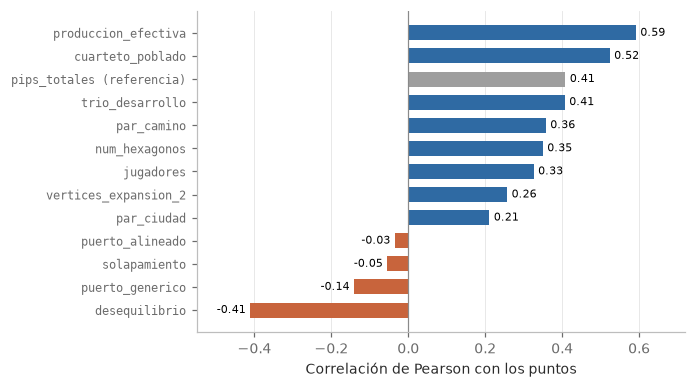

In [11]:
c = datos[VARIABLES_MODELO + ["pips_totales"]].corrwith(datos[OBJETIVO]).sort_values()
colores = [GRIS if n == "pips_totales" else (TERRACOTA if v < 0 else AZUL) for n, v in c.items()]

fig, ax = plt.subplots(figsize=(6.4, 3.6))
ax.barh(range(len(c)), c.values, color=colores, height=0.65)
ax.set_yticks(range(len(c)))
ax.set_yticklabels([n + (" (referencia)" if n == "pips_totales" else "") for n in c.index],
                   fontsize=8, family="DejaVu Sans Mono")
for i, v in enumerate(c.values):
    ax.text(v + (0.012 if v >= 0 else -0.012), i, f"{v:.2f}", va="center",
            ha="left" if v >= 0 else "right", fontsize=7.5)
ax.axvline(0, color="#8a8a8a", lw=0.8)
ax.set_xlim(-0.55, 0.72)
ax.set_xlabel("Correlación de Pearson con los puntos")
ax.grid(axis="y", visible=False)
plt.tight_layout()
plt.show()

*Documento, Capítulo 4: figura «Correlación de cada variable con los puntos simulados».*

**`produccion_efectiva` gana a `pips_totales`.** Ajustar la producción por lo que realmente
puedes gastar, descontando el excedente por su tasa de cambio, predice bastante mejor que
contar pips a secas. Los pips son la medida que usa todo el mundo en la mesa, y quedan por debajo.

**El desequilibrio resta.** Su correlación es negativa: concentrar la producción en pocos
recursos hace daño, aunque el total de pips sea alto. Es el fenómeno de acumular cartas que
no se pueden gastar.

**El puerto alineado sale casi en cero, y eso es engañoso.** No es que los puertos no sirvan:
están en la costa, y los vértices costeros tocan uno o dos hexágonos en vez de tres, así que
producen menos. La correlación simple mezcla las dos cosas. Se analiza en la Sección 5.2.

### 4.2 El hallazgo central: los pips no bastan

La intuición de cualquier jugador es colocarse donde haya más pips. Este gráfico muestra por
qué esa regla se queda corta. Una pareja «tiene madera y ladrillo» si produce al menos 3 pips
de cada uno (`par_camino >= 3`), es decir, si puede construir caminos con regularidad.

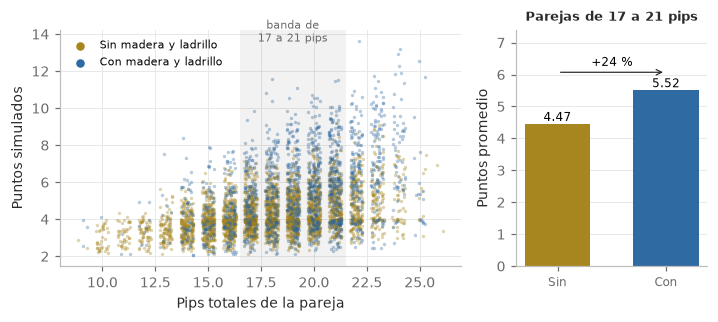

In [12]:
datos["combo"] = datos["par_camino"] >= 3
muestra = datos.sample(5000, random_state=0)
rng = np.random.default_rng(0)

fig, (a1, a2) = plt.subplots(1, 2, figsize=(6.6, 3.0), gridspec_kw={"width_ratios": [2.1, 1]})
for tiene, color, etiqueta in [(False, DORADO, "Sin madera y ladrillo"),
                               (True, AZUL, "Con madera y ladrillo")]:
    t = muestra[muestra["combo"] == tiene]
    a1.scatter(t["pips_totales"] + rng.uniform(-0.3, 0.3, len(t)), t[OBJETIVO],
               s=5, alpha=0.35, color=color, label=etiqueta, linewidths=0)
a1.axvspan(16.5, 21.5, color="black", alpha=0.05, lw=0)
a1.text(19, 13.6, "banda de\n17 a 21 pips", ha="center", fontsize=7, color=TENUE)
a1.set_xlabel("Pips totales de la pareja")
a1.set_ylabel("Puntos simulados")
leyenda = a1.legend(fontsize=7, markerscale=2.5, frameon=False, loc="upper left")
for h in leyenda.legend_handles:
    h.set_alpha(1)

b = datos[datos["pips_totales"].between(17, 21)].groupby("combo")[OBJETIVO].mean()
a2.bar([0, 1], [b[False], b[True]], color=[DORADO, AZUL], width=0.6)
for i, v in enumerate([b[False], b[True]]):
    a2.text(i, v + 0.08, f"{v:.2f}", ha="center", fontsize=8)
a2.set_xticks([0, 1])
a2.set_xticklabels(["Sin", "Con"], fontsize=8)
a2.set_ylabel("Puntos promedio")
a2.set_ylim(0, 7.4)
a2.set_title("Parejas de 17 a 21 pips", fontsize=8.5)
a2.grid(axis="x", visible=False)
a2.annotate("", xy=(1, b[True] + 0.55), xytext=(0, b[True] + 0.55),
            arrowprops=dict(arrowstyle="->", color=TINTA, lw=0.8))
a2.text(0.5, b[True] + 0.75, f"+{(b[True] / b[False] - 1) * 100:.0f} %", ha="center", fontsize=8)
plt.tight_layout()
plt.show()

*Documento, Capítulo 4: figura «Pips totales contra puntos simulados».*

In [13]:
# A igualdad de pips, ¿cuánto vale tener la combinación?
banda = datos[datos["pips_totales"].between(17, 21)]
comparacion = banda.groupby("combo")[OBJETIVO].agg(["count", "mean", "std"]).round(2)
comparacion.index = comparacion.index.map({False: "Sin madera y ladrillo", True: "Con madera y ladrillo"})
comparacion.columns = ["parejas", "puntos promedio", "desviación"]
print("Parejas de 17 a 21 pips:\n")
print(comparacion.to_string())

# Se calcula con los promedios sin redondear.
promedios = banda.groupby("combo")[OBJETIVO].mean()
diferencia = promedios[True] / promedios[False] - 1
print(f"\nDiferencia: {diferencia:+.0%} a igualdad de producción total")

Parejas de 17 a 21 pips:

                       parejas  puntos promedio  desviación
combo                                                      
Sin madera y ladrillo    14594             4.47        1.08
Con madera y ladrillo     7223             5.52        1.93

Diferencia: +24% a igualdad de producción total


Mirando el eje horizontal, las nubes suben poco: saber que una pareja tiene 21 pips en vez de
17 dice relativamente poco sobre los puntos que va a sacar.

Mirando azul contra dorado **a la misma altura de pips**, la separación es clara. La
combinación de recursos importa más que la cantidad.

**Este es el argumento del proyecto.** Si los pips predijeran bien, la app sobraría: bastaría
con contar puntitos, que es lo que ya hace todo el mundo. Que no basten es la razón de que un
modelo aporte algo.

### 4.3 Número de jugadores

           mean  median   std
jugadores                    
3.0        4.15    3.92  1.08
4.0        5.17    4.75  1.80


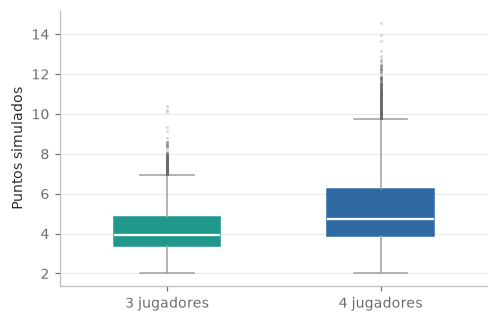

In [14]:
print(datos.groupby("jugadores")[OBJETIVO].agg(["mean", "median", "std"]).round(2))

fig, ax = plt.subplots(figsize=(4.6, 3.0))
cajas = ax.boxplot(
    [datos.loc[datos["jugadores"] == 3, OBJETIVO], datos.loc[datos["jugadores"] == 4, OBJETIVO]],
    widths=0.5, patch_artist=True,
    flierprops=dict(marker="o", ms=2, alpha=0.25, mec="none", mfc=TENUE),
    medianprops=dict(color="white", lw=1.5),
)
for caja, color in zip(cajas["boxes"], [VERDE, AZUL]):
    caja.set_facecolor(color)
    caja.set_edgecolor(color)
for linea in cajas["whiskers"] + cajas["caps"]:
    linea.set_color(GRIS)
ax.set_xticks([1, 2])
ax.set_xticklabels(["3 jugadores", "4 jugadores"])
ax.set_ylabel("Puntos simulados")
ax.grid(axis="x", visible=False)
plt.tight_layout()
plt.show()

*Documento, Capítulo 4: figura «Puntos simulados según el número de jugadores de la mesa».*

Con cuatro jugadores hay una tirada más por ronda, así que se cobra más seguido: las parejas
sacan más puntos y se separan más entre sí. Como el número de jugadores es igual para todas las
parejas de un tablero, cambia el nivel de los puntos pero no el orden entre opciones.

## 5. Análisis multivariado

### 5.1 Colinealidad: variables que dicen lo mismo

Antes de entrenar hay que detectar variables redundantes. Dos variables que miden casi lo mismo
no estropean la predicción, pero sí reparten el efecto entre sus coeficientes y los vuelven
imposibles de interpretar. Y en este proyecto los coeficientes **son** la explicación que ve el
usuario.

In [15]:
matriz = datos[variables].corr(numeric_only=True).abs()
triangulo = matriz.where(np.triu(np.ones(matriz.shape), k=1).astype(bool))
redundantes = triangulo.stack().sort_values(ascending=False)
redundantes = redundantes[redundantes > 0.85]

print(f"Pares de variables con correlación mayor a 0.85: {len(redundantes)}\n")
print(redundantes.round(3).to_string())

Pares de variables con correlación mayor a 0.85: 11

pips_trigo     control_trigo          0.963
pips_oveja     control_oveja          0.962
pips_ladrillo  control_ladrillo       0.962
pips_madera    control_madera         0.961
num_hexagonos  aristas_cercanas       0.957
pips_mineral   control_mineral        0.951
num_hexagonos  hexagonos_distintos    0.891
num_puertos    aristas_cercanas       0.871
num_hexagonos  num_puertos            0.863
pips_totales   produccion_efectiva    0.853
               control_suministro     0.853


### Decisión: qué variables se quitan

`control_<recurso>` es `pips_<recurso>` dividido entre el total de ese recurso en el tablero. Como
ese total varía poco de un tablero a otro, las dos variables acaban midiendo casi lo mismo. Se
conservan los `pips_<recurso>`, que son más fáciles de explicar a un jugador.

`aristas_cercanas`, `hexagonos_distintos` y `num_hexagonos` también van casi de la mano: todas
distinguen costa de centro. Se conserva `num_hexagonos`.

El criterio general: **ante dos variables redundantes, se queda la que sea más fácil de explicar
en voz alta**, porque el usuario final tiene que entender la recomendación. De las que quedan,
el modelo final usa un conjunto compacto de 12 (Sección 3.5 del documento).

In [16]:
descartadas = [c for c in variables if c.startswith("control_") and c != "control_suministro"]
descartadas += ["aristas_cercanas", "hexagonos_distintos"]
seleccionadas = [c for c in variables if c not in descartadas]

print(f"Se descartan {len(descartadas)}: {', '.join(descartadas)}")
print(f"\nQuedan {len(seleccionadas)} variables candidatas; el modelo final usa {len(VARIABLES_MODELO)}.")

Se descartan 8: control_madera, control_ladrillo, control_trigo, control_oveja, control_mineral, control_maximo, aristas_cercanas, hexagonos_distintos

Quedan 32 variables candidatas; el modelo final usa 12.


La matriz de correlación de las 12 variables del modelo, la misma del documento:

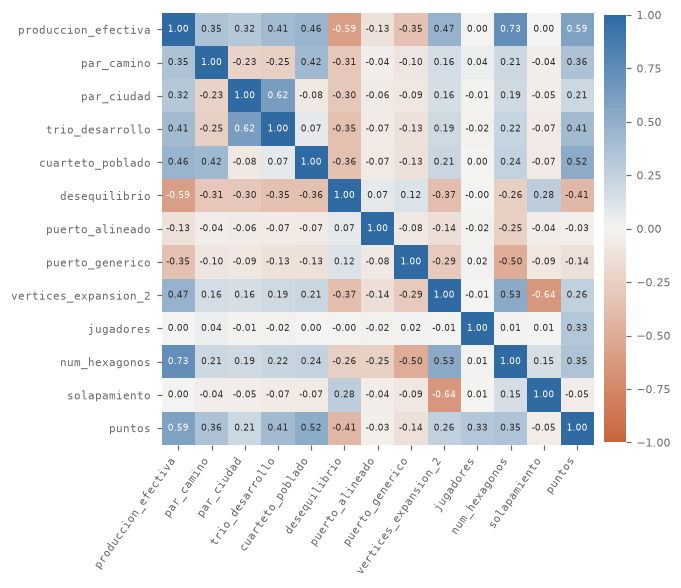

In [17]:
divergente = LinearSegmentedColormap.from_list("divergente", [TERRACOTA, "#f4f4f2", AZUL])
C = datos[VARIABLES_MODELO + [OBJETIVO]].corr()

fig, ax = plt.subplots(figsize=(6.4, 5.4))
im = ax.imshow(C.values, cmap=divergente, vmin=-1, vmax=1)
etiquetas = list(C.columns)
ax.set_xticks(range(len(etiquetas)))
ax.set_yticks(range(len(etiquetas)))
ax.set_xticklabels(etiquetas, rotation=55, ha="right", fontsize=7, family="DejaVu Sans Mono")
ax.set_yticklabels(etiquetas, fontsize=7, family="DejaVu Sans Mono")
for i in range(len(etiquetas)):
    for j in range(len(etiquetas)):
        v = C.values[i, j]
        ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=5.6,
                color="white" if abs(v) > 0.55 else TINTA)
ax.grid(False)
for borde in ax.spines.values():
    borde.set_visible(False)
barra = fig.colorbar(im, ax=ax, fraction=0.04, pad=0.02)
barra.ax.tick_params(labelsize=7)
barra.outline.set_visible(False)
plt.tight_layout()
plt.show()

*Documento, Capítulo 4: figura «Matriz de correlación de las 12 variables del modelo».*

La correlación más alta entre las 12 es de 0.73 (producción efectiva con número de hexágonos),
razonable porque una pareja que toca más hexágonos produce más. Para descartar dependencias
entre más de dos variables a la vez se calcula el **factor de inflación de la varianza (VIF)**:
cuánto se explica cada variable a partir de todas las demás. Un VIF mayor a 10 suele
considerarse problemático.

In [18]:
from sklearn.linear_model import LinearRegression

vif = {}
for v in VARIABLES_MODELO:
    otras = [x for x in VARIABLES_MODELO if x != v]
    r2 = LinearRegression().fit(datos[otras], datos[v]).score(datos[otras], datos[v])
    vif[v] = 1 / (1 - r2)
pd.Series(vif, name="VIF").sort_values(ascending=False).round(2).to_frame()

,VIF
vertices_expansion_2,5.47
num_hexagonos,5.02
produccion_efectiva,4.46
solapamiento,4.16
trio_desarrollo,2.06
desequilibrio,2.00
par_ciudad,1.79
par_camino,1.70
cuarteto_poblado,1.51
puerto_generico,1.44


### 5.2 La paradoja del puerto

Por experiencia de juego, concentrar un recurso y tener su puerto 2:1 es una buena jugada. Pero
en los datos, las parejas con puerto alineado sacan en promedio **menos** puntos. La paradoja se
resuelve al comparar parejas con una producción parecida.

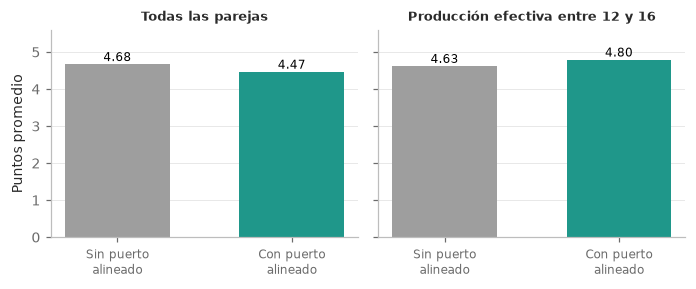

In [19]:
todas = datos.groupby(datos["puerto_alineado"] > 0)[OBJETIVO].mean()
misma_produccion = datos[datos["produccion_efectiva"].between(12, 16)]
controlado = misma_produccion.groupby(misma_produccion["puerto_alineado"] > 0)[OBJETIVO].mean()

fig, (a1, a2) = plt.subplots(1, 2, figsize=(6.4, 2.7), sharey=True)
for ax, g, titulo in [(a1, todas, "Todas las parejas"),
                      (a2, controlado, "Producción efectiva entre 12 y 16")]:
    ax.bar([0, 1], [g[False], g[True]], color=[GRIS, VERDE], width=0.6)
    for i, v in enumerate([g[False], g[True]]):
        ax.text(i, v + 0.08, f"{v:.2f}", ha="center", fontsize=8)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["Sin puerto\nalineado", "Con puerto\nalineado"], fontsize=8)
    ax.set_title(titulo, fontsize=8.5)
    ax.grid(axis="x", visible=False)
a1.set_ylabel("Puntos promedio")
a1.set_ylim(0, 5.6)
plt.tight_layout()
plt.show()

*Documento, Capítulo 4: figura «Puntos promedio con y sin puerto alineado».*

In [20]:
# ¿Por qué? Las parejas con puerto alineado están en la costa: tocan menos hexágonos y producen menos.
datos.groupby(datos["puerto_alineado"] > 0)[["num_hexagonos", "pips_totales", "produccion_efectiva"]] \
    .mean().round(2).rename(index={False: "sin puerto alineado", True: "con puerto alineado"})

,num_hexagonos,pips_totales,produccion_efectiva
puerto_alineado,,,
sin puerto alineado,5.19,18.49,13.69
con puerto alineado,4.38,15.85,12.20


Es una **variable de confusión**. La comparación simple mezcla dos efectos opuestos: «tener
puerto» (positivo) y «estar en la costa y producir menos» (negativo), y el segundo domina. A
igual producción, el puerto sí ayuda. Un modelo que considere la producción y el número de
hexágonos al mismo tiempo puede separar los dos efectos; por eso ambas variables entran al
modelo junto con el puerto, y en `02_modelo.ipynb` el coeficiente del puerto sale positivo.

## 6. La partición tiene que ser por tablero

Las ~192 parejas de un mismo tablero comparten los mismos 19 hexágonos con los mismos números.
Si unas caen en entrenamiento y otras en prueba, el modelo ve en el entrenamiento información
del tablero que va a evaluar, y la métrica puede salir inflada.

La partición correcta es **por `tablero_id`**: un tablero entero va a entrenamiento o a prueba,
nunca partido. Aquí se comparan las dos formas de partir, con las 12 variables del modelo.

In [21]:
from sklearn.metrics import r2_score
from sklearn.model_selection import GroupShuffleSplit, train_test_split

X, y = datos[VARIABLES_MODELO], datos[OBJETIVO]

# Partición ingenua, por fila: incorrecta para este problema
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.25, random_state=0)
r2_fila = r2_score(yte, LinearRegression().fit(Xtr, ytr).predict(Xte))

# Partición correcta, por tablero
particion = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=0)
i_tr, i_te = next(particion.split(X, y, groups=datos["tablero_id"]))
r2_tablero = r2_score(
    y.iloc[i_te],
    LinearRegression().fit(X.iloc[i_tr], y.iloc[i_tr]).predict(X.iloc[i_te]),
)

print(f"R² con partición por fila (incorrecta):  {r2_fila:.3f}")
print(f"R² con partición por tablero (correcta): {r2_tablero:.3f}")

R² con partición por fila (incorrecta):  0.633
R² con partición por tablero (correcta): 0.642


La diferencia entre las dos particiones resulta **pequeña** con este dataset, y conviene decirlo
en vez de exagerar el riesgo. La razón es que las variables describen la pareja en sí, no el
tablero: un modelo que aprendió que la madera con ladrillo rinde bien aplica igual en un tablero
que no ha visto.

Aun así, la partición por tablero se conserva. Es la que corresponde a cómo se usa el modelo de
verdad: la app recibe tableros nuevos, no parejas sueltas de tableros ya conocidos.

## 7. Conclusiones del análisis exploratorio

Son las mismas de la Sección 4.4 del documento.

**El dataset está completo y es consistente.** Sin valores faltantes ni duplicados. Los valores
extremos corresponden a las mejores parejas, no a errores, así que se conservan.

**Las posiciones de un tablero valen muy distinto.** La mejor pareja de cada tablero saca casi
el doble de puntos que la pareja típica.

**Los pips no bastan.** La medida que usa todo jugador en la mesa queda por debajo de
`produccion_efectiva`, y a igualdad de pips, entre 17 y 21, las parejas que completan madera con
ladrillo sacan alrededor de un 24 % más de puntos. Este es el hallazgo que justifica el producto.

**El desequilibrio hace daño.** Concentrar la producción correlaciona en negativo con los puntos,
aunque el total sea alto.

**Las 12 variables del modelo no son redundantes.** Ningún VIF supera 5.5, así que los
coeficientes de la regresión serán interpretables. Es la condición para que la app pueda
explicarle al usuario por qué recomienda lo que recomienda.

**Algunas relaciones solo se ven controlando por otras variables**, como el efecto del puerto.
Esto justifica un modelo multivariado en lugar de reglas basadas en una sola variable.

Siguiente paso: `02_modelo.ipynb`, con la regresión, su evaluación y el agrupamiento de
estrategias.